In [8]:
!gdown --id 1CLqld838ql2yNPVahJYTSdP-XHpYB7JB
!gdown --id 1qJkIEp1U3T9oNqhvKcuz_q2ZHgrzOxSG

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1CLqld838ql2yNPVahJYTSdP-XHpYB7JB
From (redirected): https://drive.google.com/uc?id=1CLqld838ql2yNPVahJYTSdP-XHpYB7JB&confirm=t&uuid=115f3d61-cd5f-43bc-aa57-7ada078b1e21
To: /kaggle/working/t_phipt.npy
100%|████████████████████████████████████████| 786M/786M [00:12<00:00, 62.1MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1qJkIEp1U3T9oNqhvKcuz_q2ZHgrzOxSG
From (redirected): https://drive.google.com/uc?id=1qJkIEp1U3T9oNqhvKcuz_q2ZHgrzOxSG&confirm=t&uuid=65b2f071-d3d9-4d

In [1]:
import numpy as np

from keras import layers
from keras.models import Model
import keras

from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

from keras import layers, models


2026-06-03 20:37:51.505566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780519071.914747      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780519072.013466      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780519072.768247      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780519072.768309      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780519072.768312      58 computation_placer.cc:177] computation placer alr

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [10]:
bb = np.load('/kaggle/working/b_phipt.npy').reshape((-1, 64, 64, 1))
tt = np.load('/kaggle/working/t_phipt.npy').reshape((-1, 64, 64, 1))

In [11]:
X = np.append(bb, tt, axis=0)
# Test these before going further
X_log  = np.log1p(X)
X_sqrt = np.sqrt(X)
X_norm =  X / (np.sum(X, axis=(1, 2), keepdims=True) + 1e-8)  # +epsilon to avoid div-by-zero for empty events

Y = np.append(np.ones(len(bb)), np.zeros(len(tt))).reshape((-1, 1))


In [12]:
# Load  model 
model_sqrt = tf.keras.models.load_model('/kaggle/input/datasets/aswin47/models/sqrt.h5')
model_l1 = tf.keras.models.load_model('/kaggle/input/datasets/aswin47/models/l1.h5')
model_log = tf.keras.models.load_model('/kaggle/input/datasets/aswin47/models/log.h5')
model_raw = tf.keras.models.load_model('/kaggle/input/datasets/aswin47/models/raw.h5')




# Get the last conv layer name
# model.summary()
# last_conv_layer_name = [layer.name for layer in model.layers if 'conv' in layer.name][-1]
# print("Using last conv layer:", last_conv_layer_name)


In [15]:

# Grad-CAM function (FIXED)
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # Ensure predictions is the actual tensor, not a list containing it
        output_tensor = predictions[0] if isinstance(predictions, list) else predictions

        if pred_index is None:
            # Get the index of the highest prediction. For a batch size of 1,
            # this ensures a scalar index is used. axis=1 for class dimension, [0] to get scalar.
            pred_index = tf.argmax(output_tensor, axis=1)[0]

        # Now use output_tensor (which is a TF tensor) with the pred_index (which is a scalar TF tensor)
        # This will correctly index the predicted class score(s)
        class_output = output_tensor[:, pred_index]

    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
   # heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = tf.abs(heatmap) / (tf.math.reduce_max(tf.abs(heatmap)) + 1e-8)
    return heatmap.numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 64, 64, 1))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 64, 64, 1))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 64, 64, 1))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 64, 64, 1))
  warnings.warn(msg)


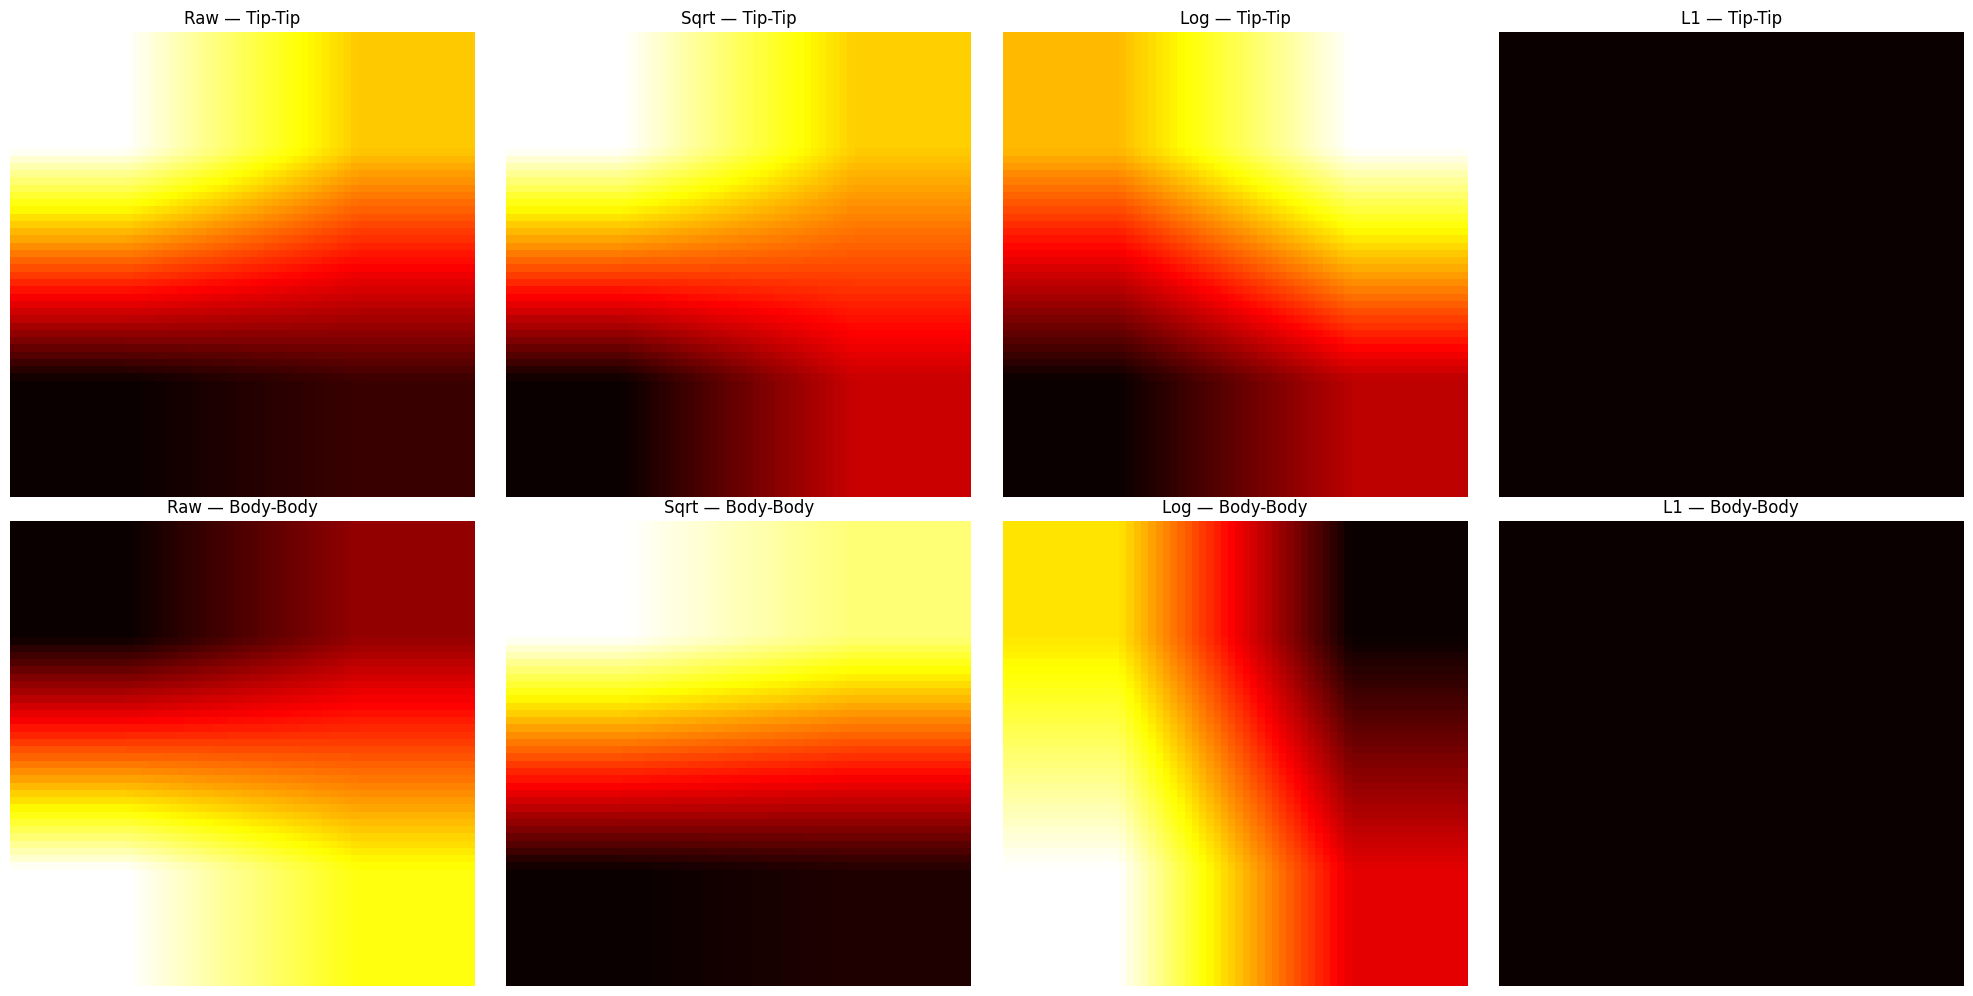

In [16]:
models = {
    'Raw':  model_raw,
    'Sqrt': model_sqrt,
    'Log':  model_log,
    'L1':   model_l1
}

X_inputs = {
    'Raw':  X,
    'Sqrt': X_sqrt,
    'Log':  X_log,
    'L1':   X_norm
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col, (name, mdl) in enumerate(models.items()):
    tip_heatmaps, body_heatmaps = [], []
    
    X_in = X_inputs[name]
    X_tr, X_te, Y_tr, Y_te = train_test_split(
        X_in, Y, test_size=0.2, stratify=Y, random_state=42)
    Y_te_cat = to_categorical(Y_te)
    
    tip_idx  = np.where(np.argmax(Y_te_cat, axis=1) == 0)[0][:100]
    body_idx = np.where(np.argmax(Y_te_cat, axis=1) == 1)[0][:100]
    
    last_conv = [l.name for l in mdl.layers if 'conv' in l.name][-1]
    
    for i in tip_idx:
        img = np.expand_dims(X_te[i], axis=0)
        h = make_gradcam_heatmap(img, mdl, last_conv)
        tip_heatmaps.append(cv2.resize(h, (64, 64)))
    
    for i in body_idx:
        img = np.expand_dims(X_te[i], axis=0)
        h = make_gradcam_heatmap(img, mdl, last_conv)
        body_heatmaps.append(cv2.resize(h, (64, 64)))
    
    avg_tip  = np.mean(np.stack(tip_heatmaps), axis=0)
    avg_body = np.mean(np.stack(body_heatmaps), axis=0)
    
    axes[0, col].imshow(avg_tip,  cmap='hot')
    axes[0, col].set_title(f'{name} — Tip-Tip')
    axes[0, col].axis('off')
    
    axes[1, col].imshow(avg_body, cmap='hot')
    axes[1, col].set_title(f'{name} — Body-Body')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('gradcam_comparison_all.png', dpi=150)
plt.show()

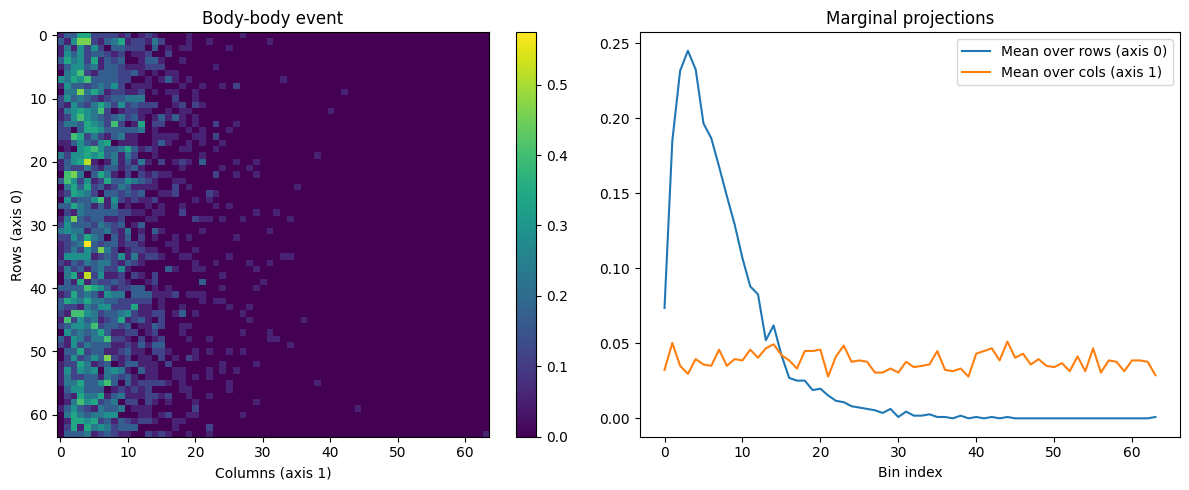

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(bb[0].squeeze(), cmap='viridis', aspect='auto')
axes[0].set_xlabel('Columns (axis 1)')
axes[0].set_ylabel('Rows (axis 0)')
axes[0].set_title('Body-body event')
axes[0].colorbar = plt.colorbar(axes[0].images[0], ax=axes[0])

# Check marginal projections to identify axes
axes[1].plot(bb[0].squeeze().mean(axis=0), label='Mean over rows (axis 0)')
axes[1].plot(bb[0].squeeze().mean(axis=1), label='Mean over cols (axis 1)')
axes[1].legend()
axes[1].set_title('Marginal projections')
axes[1].set_xlabel('Bin index')

plt.tight_layout()
plt.show()

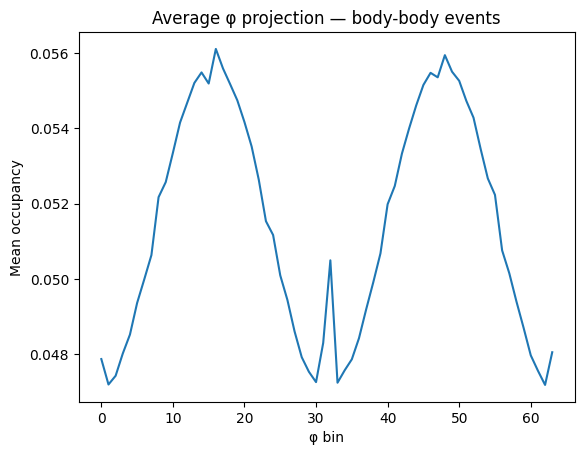

In [18]:
# Quick check: is φ distribution symmetric across events?
avg_phi_projection = bb.squeeze().mean(axis=(0, 2))  # mean over events and pt
plt.plot(avg_phi_projection)
plt.xlabel("φ bin")
plt.ylabel("Mean occupancy")
plt.title("Average φ projection — body-body events")
plt.show()

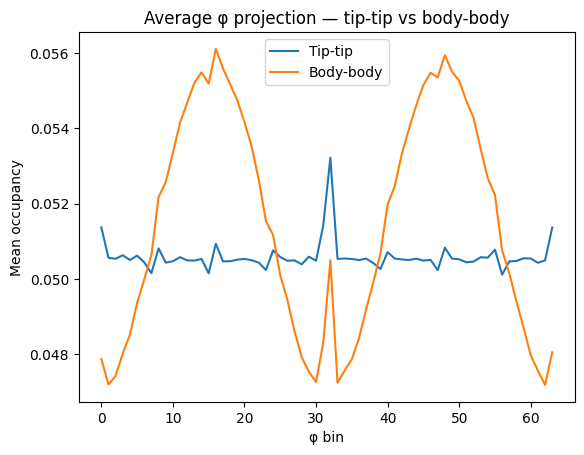

In [19]:
avg_phi_tt = tt.squeeze().mean(axis=(0, 2))  # mean over events and pt bins
avg_phi_bb = bb.squeeze().mean(axis=(0, 2))

plt.plot(avg_phi_tt, label='Tip-tip')
plt.plot(avg_phi_bb, label='Body-body')
plt.xlabel("φ bin")
plt.ylabel("Mean occupancy")
plt.title("Average φ projection — tip-tip vs body-body")
plt.legend()
plt.show()